In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress minor warnings
warnings.filterwarnings('ignore')

# Set a style for all plots
sns.set_theme(style="whitegrid")

print("--- Libraries Imported and Setup Complete ---")

--- Libraries Imported and Setup Complete ---


In [2]:
# =============================================================================
# 1. DATA LOADING
# =============================================================================
print("\n--- 1. Data Loading ---")
try:
    # Use sep=';' as the file is semicolon-delimited
    file_path = r'C:\Users\suraj\OneDrive\Desktop\student\student-mat.csv'
    df = pd.read_csv(file_path, sep=';')
    print(f"Dataset from '{file_path}' loaded successfully.")
    
    # Display the first few rows
    print("\nFirst 5 rows of the dataset:")
    print(df.head())

except FileNotFoundError:
    print(f"FILE NOT FOUND: Could not find file at '{file_path}'.")
    print("Please check the file path and make sure the file exists.")
    
except Exception as e:
    print(f"An error occurred during loading: {e}")


--- 1. Data Loading ---
Dataset from 'C:\Users\suraj\OneDrive\Desktop\student\student-mat.csv' loaded successfully.

First 5 rows of the dataset:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1 

In [3]:
# =============================================================================
# 2. DATA EXPLORATION
# =============================================================================
print("\n--- 2. Data Exploration ---")

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())
print("\n------------------------------")

# Display column data types and non-null counts (more detailed than .dtypes)
print("Data types and info:")
df.info()
print("\n------------------------------")

# Understand the dataset's size
rows, cols = df.shape
print(f"The dataset has {rows} rows and {cols} columns.")


--- 2. Data Exploration ---

Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

------------------------------
Data types and info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4  

In [4]:
# =============================================================================
# 3. DATA CLEANING
# =============================================================================
print("\n--- 3. Data Cleaning ---")

# Handle missing values (Based on exploration, there are none)
missing_count = df.isnull().sum().sum()
if missing_count == 0:
    print("No missing values found. No imputation needed.")
else:
    print(f"Found {missing_count} missing values. Handling them...")
    # Add code here to handle missing values if any were found

# Remove duplicate entries
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
cleaned_rows = df.shape[0]

print(f"Removed {initial_rows - cleaned_rows} duplicate rows.")
print(f"The dataset now has {cleaned_rows} unique rows.")


--- 3. Data Cleaning ---
No missing values found. No imputation needed.
Removed 0 duplicate rows.
The dataset now has 395 unique rows.


In [5]:
# =============================================================================
# 4. DATA ANALYSIS QUESTIONS
# =============================================================================
print("\n--- 4. Data Analysis Questions ---")

# 1. What is the average score in math (G3)?
avg_g3 = df['G3'].mean()
print(f"\n1. The average final math score (G3) is: {avg_g3:.2f}")

# 2. How many students scored above 15 in their final grade (G3)?
students_above_15 = df[df['G3'] > 15].shape[0]
print(f"\n2. Number of students scoring above 15 in G3: {students_above_15}")

# 3. Is there a correlation between study time (studytime) and G3?
correlation = df['studytime'].corr(df['G3'])
print(f"\n3. Correlation between study time and G3: {correlation:.4f}")

# 4. Which gender has a higher average final grade (G3)?
avg_by_gender = df.groupby('sex')['G3'].mean()
print("\n4. Average final grade (G3) by gender:")
print(avg_by_gender)

higher_gender = avg_by_gender.idxmax()
higher_score = avg_by_gender.max()
print(f"   Result: {higher_gender} students have a higher average grade ({higher_score:.2f}).")


--- 4. Data Analysis Questions ---

1. The average final math score (G3) is: 10.42

2. Number of students scoring above 15 in G3: 40

3. Correlation between study time and G3: 0.0978

4. Average final grade (G3) by gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64
   Result: M students have a higher average grade (10.91).



--- 5.1 Visualization: Histogram of Final Grades ---
Saved: 'g3_histogram.png'


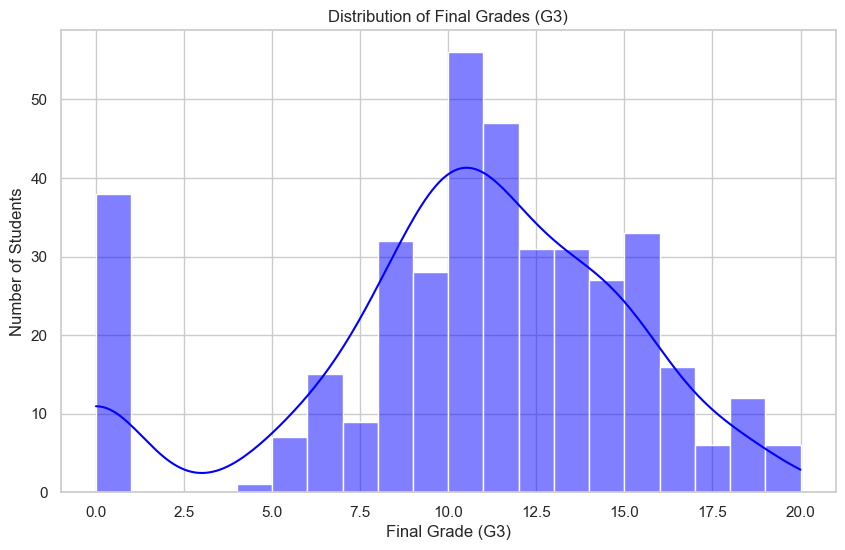

In [6]:
# =============================================================================
# 5. DATA VISUALIZATION (Plot 1)
# =============================================================================
print("\n--- 5.1 Visualization: Histogram of Final Grades ---")

# 1. Plot a histogram of final grades (G3)
plt.figure(figsize=(10, 6))
sns.histplot(df['G3'], bins=20, kde=True, color='blue')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.savefig('g3_histogram.png')
print("Saved: 'g3_histogram.png'")
plt.show()


--- 5.1 Visualization: Histogram of Final Grades ---
Saved: 'g3_histogram.png'


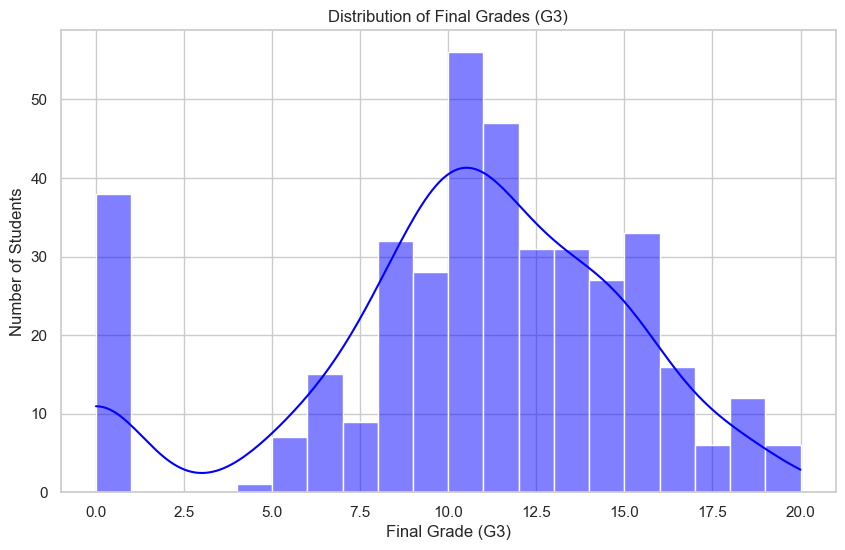

In [7]:
# =============================================================================
# 5. DATA VISUALIZATION (Plot 1)
# =============================================================================
print("\n--- 5.1 Visualization: Histogram of Final Grades ---")

# 1. Plot a histogram of final grades (G3)
plt.figure(figsize=(10, 6))
sns.histplot(df['G3'], bins=20, kde=True, color='blue')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.savefig('g3_histogram.png')
print("Saved: 'g3_histogram.png'")
plt.show()


--- 5.3 Visualization: Average Grade by Gender ---
Saved: 'avg_g3_by_gender_bar.png'


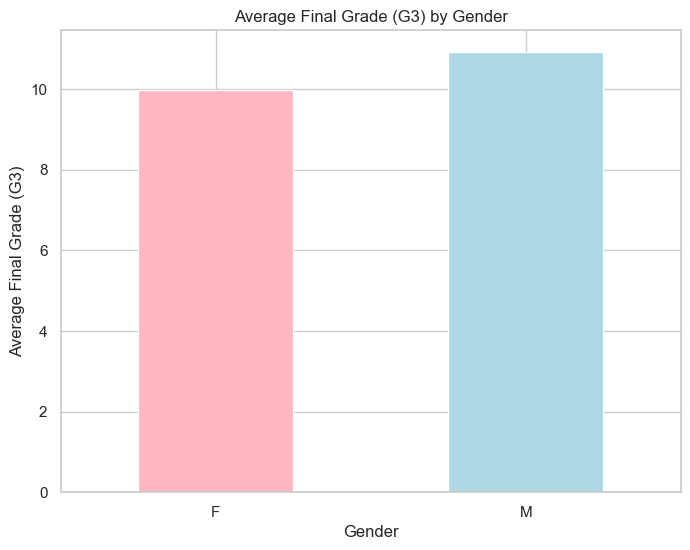


--- ANALYSIS COMPLETE ---


In [8]:
# =============================================================================
# 5. DATA VISUALIZATION (Plot 3)
# =============================================================================
print("\n--- 5.3 Visualization: Average Grade by Gender ---")

# 3. Create a bar chart comparing the average scores of male and female students
plt.figure(figsize=(8, 6))
avg_by_gender.plot(kind='bar', color=['lightpink', 'lightblue'])
plt.title('Average Final Grade (G3) by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Final Grade (G3)')
plt.xticks(rotation=0)  # Keep the x-axis labels (F, M) horizontal
plt.savefig('avg_g3_by_gender_bar.png')
print("Saved: 'avg_g3_by_gender_bar.png'")
plt.show()

print("\n--- ANALYSIS COMPLETE ---")